In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("../data/raw")

# Load one file to understand structure
sample_file = sorted(DATA_DIR.iterdir())[0]
df = pd.read_csv(sample_file, sep="\t", header=None)
df.columns = ["bearing_1", "bearing_2", "bearing_3", "bearing_4"]

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nBasic stats:")
print(df.describe())

Shape: (20480, 4)

First 5 rows:
   bearing_1  bearing_2  bearing_3  bearing_4
0     -0.049     -0.071     -0.132     -0.010
1     -0.042     -0.073     -0.007     -0.105
2      0.015      0.000      0.007      0.000
3     -0.051      0.020     -0.002      0.100
4     -0.107      0.010      0.127      0.054

Basic stats:
          bearing_1     bearing_2     bearing_3     bearing_4
count  20480.000000  20480.000000  20480.000000  20480.000000
mean      -0.010196     -0.012695     -0.014541     -0.010026
std        0.073477      0.090056      0.108436      0.053168
min       -0.386000     -0.513000     -0.911000     -0.264000
25%       -0.059000     -0.073000     -0.081000     -0.046000
50%       -0.010000     -0.015000     -0.015000     -0.010000
75%        0.037000      0.046000      0.051000      0.027000
max        0.454000      0.464000      1.023000      0.193000


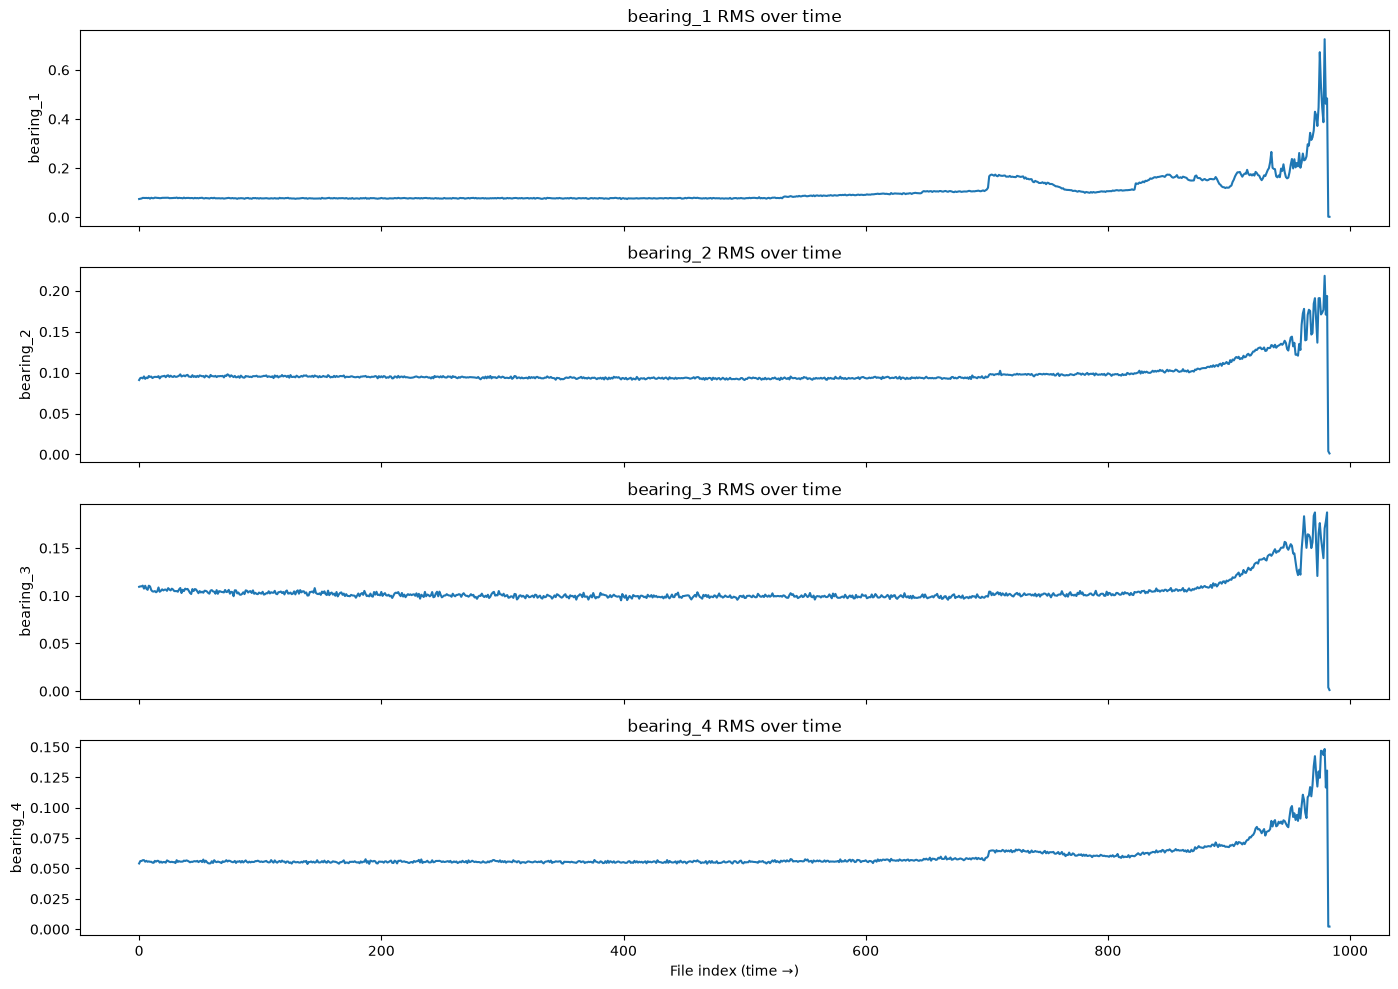


Final 5 RMS values (near failure):
                     bearing_1  bearing_2  bearing_3  bearing_4
timestamp                                                      
2004.02.19.05.42.39   0.725001   0.218294   0.170577   0.148351
2004.02.19.05.52.39   0.462012   0.170817   0.177878   0.116630
2004.02.19.06.02.39   0.483835   0.193641   0.187405   0.130582
2004.02.19.06.12.39   0.002103   0.004018   0.003950   0.002154
2004.02.19.06.22.39   0.001533   0.001239   0.001197   0.002124


In [2]:
# Load all files and compute RMS (Root Mean Square) per file per bearing
# RMS captures energy in the signal — rises as bearing degrades

files = sorted(DATA_DIR.iterdir())

rms_records = []
for f in files:
    df = pd.read_csv(f, sep="\t", header=None)
    df.columns = ["bearing_1", "bearing_2", "bearing_3", "bearing_4"]
    rms = df.apply(lambda x: np.sqrt(np.mean(x**2)))
    rms["timestamp"] = f.name
    rms_records.append(rms)

rms_df = pd.DataFrame(rms_records).set_index("timestamp")

# Plot
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for i, col in enumerate(["bearing_1", "bearing_2", "bearing_3", "bearing_4"]):
    axes[i].plot(rms_df[col].values)
    axes[i].set_ylabel(col)
    axes[i].set_title(f"{col} RMS over time")

plt.xlabel("File index (time →)")
plt.tight_layout()
plt.show()

print("\nFinal 5 RMS values (near failure):")
print(rms_df.tail())

In [3]:
print(f"Total files: {len(files)}")
print(f"First file: {files[0].name}")
print(f"Last file: {files[-1].name}")

# Check for consistent row counts
row_counts = []
for f in files:
    df = pd.read_csv(f, sep="\t", header=None)
    row_counts.append(len(df))

print(f"\nUnique row counts: {set(row_counts)}")
print(f"Min rows: {min(row_counts)}, Max rows: {max(row_counts)}")

Total files: 984
First file: 2004.02.12.10.32.39
Last file: 2004.02.19.06.22.39

Unique row counts: {20480}
Min rows: 20480, Max rows: 20480
